# House Price Prediction Using Machine Learning

## Project Category
Regression

## Objective
The objective of this project is to predict house prices using machine learning regression algorithms.

## Algorithms Used
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

## Evaluation Metrics
- MAE
- RMSE
- R2 Score

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor)

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

In [ ]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names)

df["HousePrice"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:")
print(df.duplicated().sum())

Shape: (20640, 9)

Columns:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HousePrice'],
      dtype='object')

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

Duplicate Values:
0


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


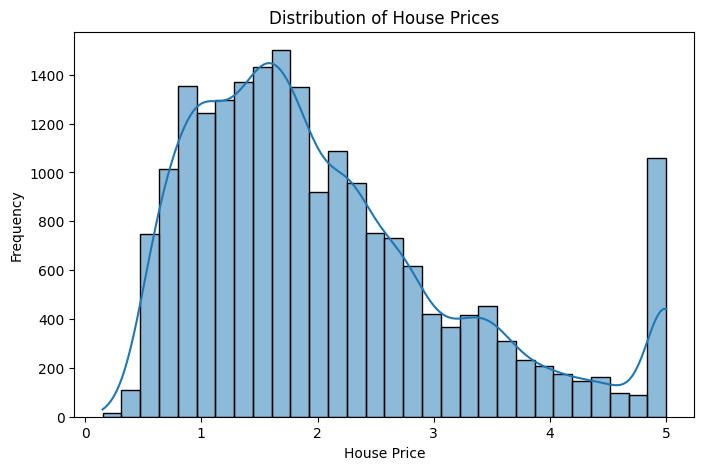

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["HousePrice"],
    bins=30,
    kde=True)

plt.title("Distribution of House Prices")

plt.xlabel("House Price")

plt.ylabel("Frequency")

plt.show()

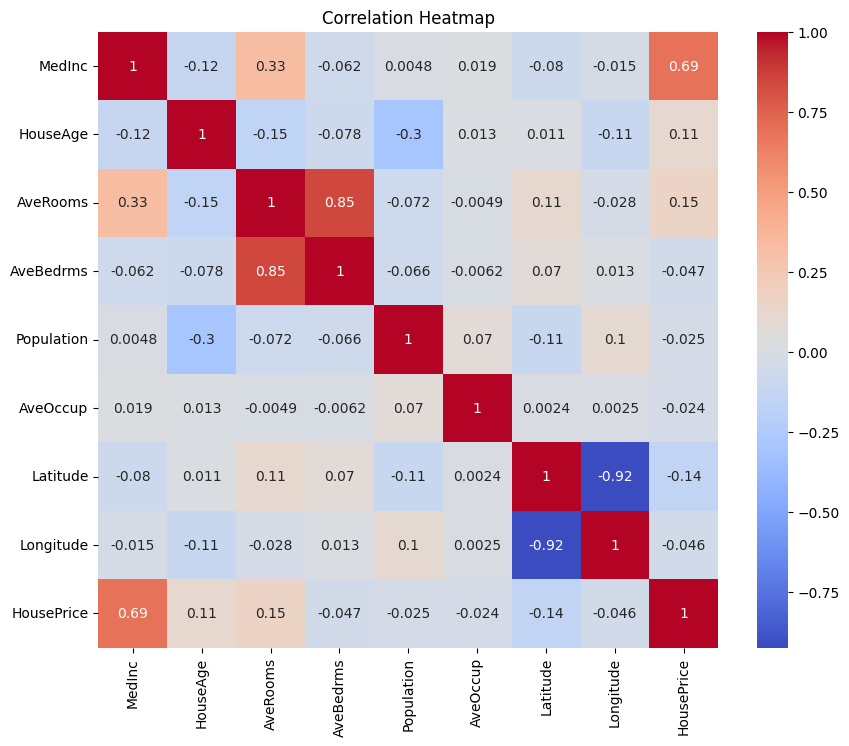

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

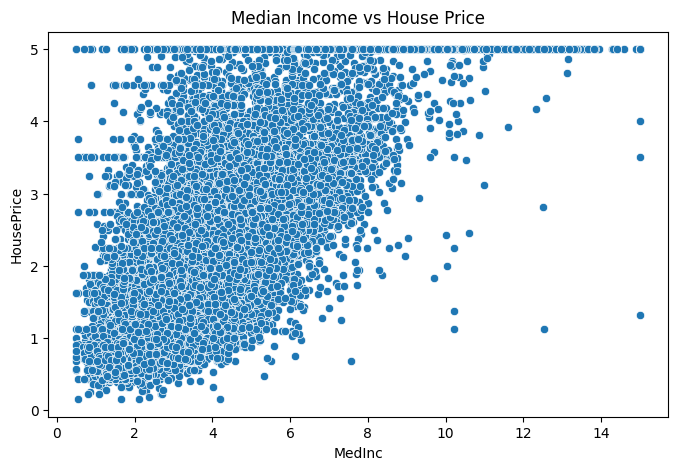

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["MedInc"],
    y=df["HousePrice"])

plt.title("Median Income vs House Price")

plt.show()

## Medyan Gelir ve Konut Fiyatı Analizi

Scatterplot grafiği, medyan gelir (MedInc) ile konut fiyatları (HousePrice) arasındaki ilişkiyi incelemek amacıyla kullanılmıştır.

### Gözlemler

- Medyan gelir ile konut fiyatları arasında belirgin pozitif ilişki gözlemlenmiştir.
- Medyan gelir arttıkça konut fiyatlarının da artma eğiliminde olduğu görülmektedir.
- İlişki tamamen doğrusal değildir; veri setinde doğrusal olmayan örüntüler bulunmaktadır.
- Yüksek gelir seviyelerinde bazı aykırı gözlemler (outlier) dikkat çekmektedir.
- Maksimum hedef değer çevresindeki yatay yoğunlaşma, veri setinde üst sınırlandırılmış fiyat değerleri olabileceğini göstermektedir.

### Yorum

Bu görselleştirme, medyan gelir değişkeninin konut fiyatlarını etkileyen en önemli değişkenlerden biri olduğunu doğrulamaktadır.

Veri yapısındaki doğrusal olmayan ilişkiler nedeniyle Random Forest, Gradient Boosting ve XGBoost gibi ensemble tabanlı modellerin kullanılması uygun görülmüştür.

In [ ]:
X = df.drop("HousePrice", axis=1)

y = df["HousePrice"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost" ],

    "MAE": [

        mean_absolute_error(y_test, lr_pred),

        mean_absolute_error(y_test, dt_pred),

        mean_absolute_error(y_test, rf_pred),

        mean_absolute_error(y_test, gb_pred),

        mean_absolute_error(y_test, xgb_pred)],
    "RMSE": [

        np.sqrt(mean_squared_error(y_test, lr_pred)),

        np.sqrt(mean_squared_error(y_test, dt_pred)),

        np.sqrt(mean_squared_error(y_test, rf_pred)),

        np.sqrt(mean_squared_error(y_test, gb_pred)),

        np.sqrt(mean_squared_error(y_test, xgb_pred))    ],

    "R2 Score": [

        r2_score(y_test, lr_pred),

        r2_score(y_test, dt_pred),

        r2_score(y_test, rf_pred),

        r2_score(y_test, gb_pred),

        r2_score(y_test, xgb_pred)]})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.533200,0.745581,0.575788
1,Decision Tree,0.454679,0.703729,0.622076
2,Random Forest,0.326812,0.503960,0.806186
3,Gradient Boosting,0.371643,0.542215,0.775645
4,XGBoost,0.317128,0.478722,0.825112


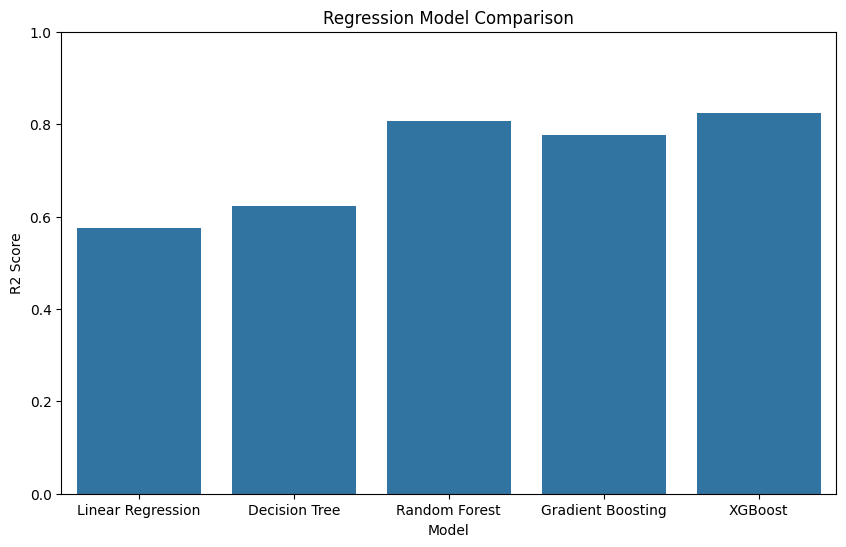

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=results)

plt.title("Regression Model Comparison")

plt.ylim(0,1)

plt.show()